In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Libraries

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from google.colab import files


Reading Dataset

In [ ]:
#Import path
DATASET_PATH = '/content/drive/MyDrive/Colab Notebooks/nnfllproject/weather dataset'
TRAIN_DIR = os.path.join(DATASET_PATH, 'train')
VAL_DIR = os.path.join(DATASET_PATH, 'validation')

# Define hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
class_names = ['cloudy', 'rain', 'shine', 'sunrise']

# Check if dataset exists
if not os.path.exists(TRAIN_DIR):
    print(f"Error: Training directory not found at {TRAIN_DIR}")
else:
    print(f"Dataset found at {DATASET_PATH}")
    print(f"Classes: {os.listdir(TRAIN_DIR)}")

Dataset found at /content/drive/MyDrive/Colab Notebooks/nnfllproject/weather dataset
Classes: ['shine', 'rain', 'sunrise', 'cloudy']


EDA


               Exploratory Data Analysis (EDA)

1.Class Distribution & Statistics
------------------------------------------------------------

Training Set:
 cloudy    :  240 images ( 26.7%)
 rain      :  172 images ( 19.1%)
 shine     :  202 images ( 22.4%)
 sunrise   :  286 images ( 31.8%)
 Total     :  900 images

Validation Set:
 cloudy    :   60 images ( 26.7%)
 rain      :   43 images ( 19.1%)
 shine     :   51 images ( 22.7%)
 sunrise   :   71 images ( 31.6%)
 Total     :  225 images

Train/Val Split: 80.0% / 20.0%
Class Imbalance Ratio: 1.66:1Warning: Significant imbalance!


2. Class Distribution Visualization
------------------------------------------------------------


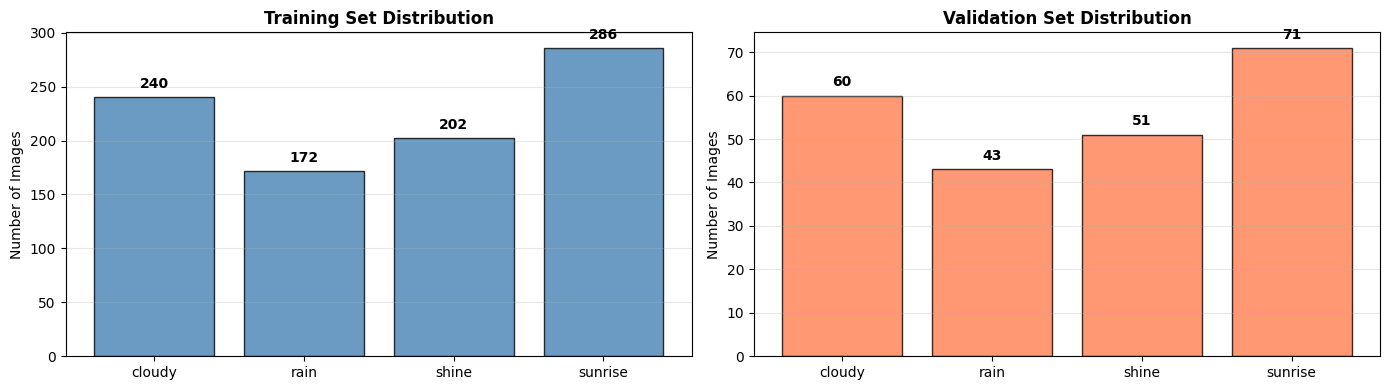


3. Sample Images from Each Class
------------------------------------------------------------


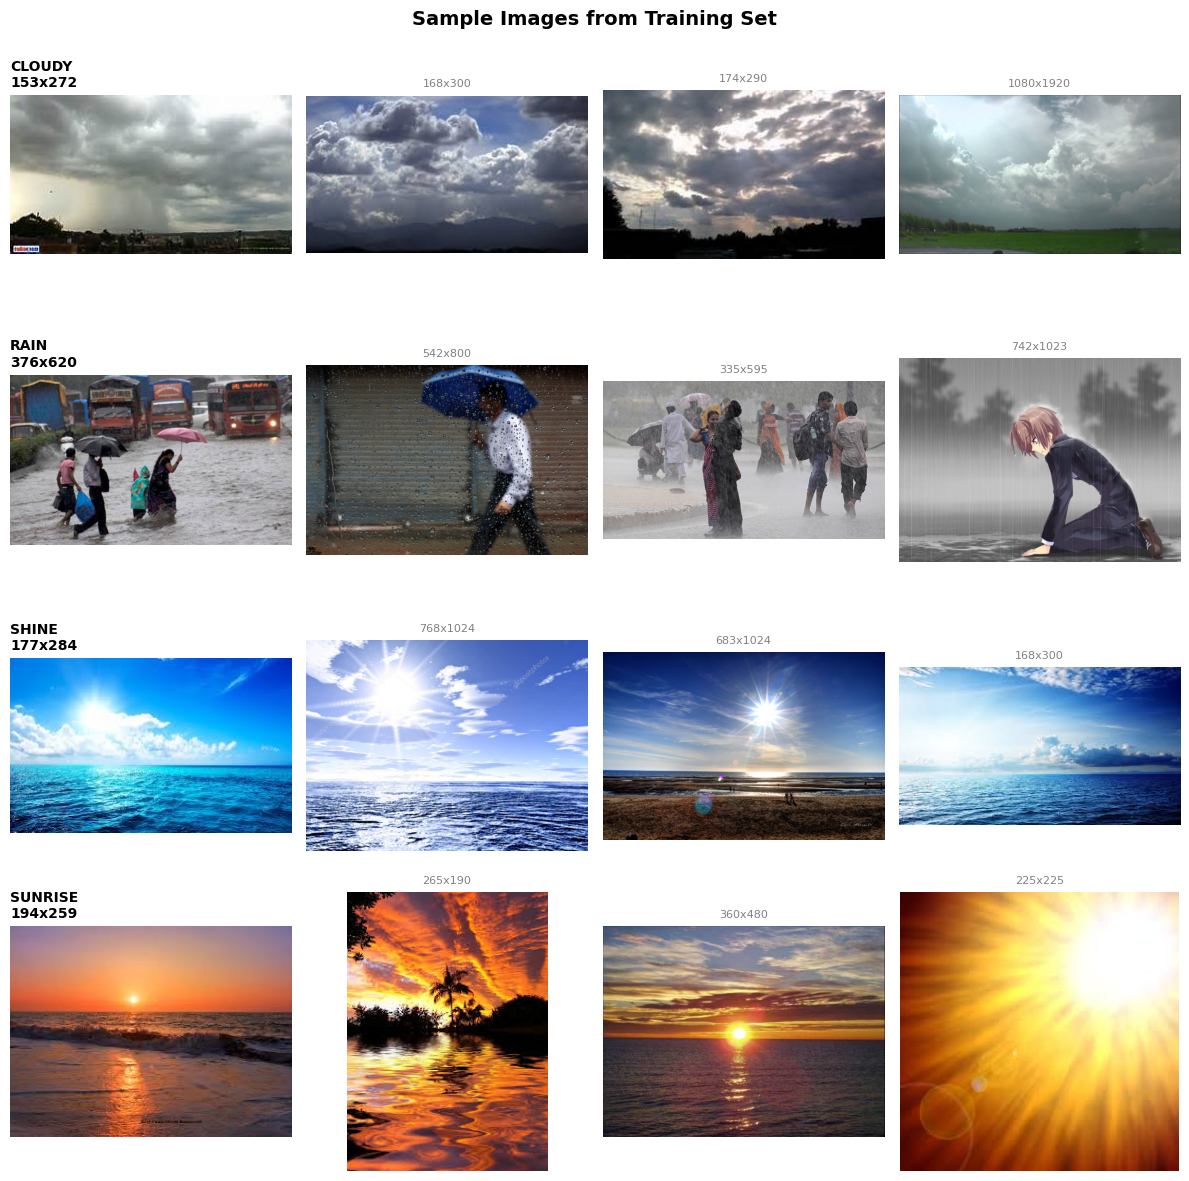


4.Image Dimensions Analysis
------------------------------------------------------------
Analyzing image dimensions (sampling 50 images)...

Dimensions Summary (from 60 images):
 Width - Min:  190px | Max: 4261px | Avg:  555.8px
 Height - Min:  153px | Max: 3195px | Avg:  367.2px
 Target resize: 224x224px
 Unique dimensions: 44
Images have varying dimensions (will be resized)

5. Dataset Summary
------------------------------------------------------------
Total Images : 1,125
Training Images : 900 (80.0%)
Validation Images : 225 (20.0%)
Number of Classes : 4

EDA Completed!
Visualizations saved to: /content/drive/MyDrive/Colab Notebooks/nnfllproject/saved_models



In [ ]:
print("\n" + "="*60)
print(" "*15 + "Exploratory Data Analysis (EDA)")
print("="*60 + "\n")

# Class Distribution & Statistics
print("1.Class Distribution & Statistics")
print("-" * 60)

train_class_counts = {}
val_class_counts = {}

for class_name in class_names:
    train_path = os.path.join(TRAIN_DIR, class_name)
    val_path = os.path.join(VAL_DIR, class_name)
    train_class_counts[class_name] = len(os.listdir(train_path))
    val_class_counts[class_name] = len(os.listdir(val_path))

total_train = sum(train_class_counts.values())
total_val = sum(val_class_counts.values())

print("\nTraining Set:")
for class_name, count in train_class_counts.items():
    percentage = (count / total_train) * 100
    print(f" {class_name:10s}: {count:4d} images ({percentage:5.1f}%)")
print(f" {'Total':10s}: {total_train:4d} images")

print("\nValidation Set:")
for class_name, count in val_class_counts.items():
    percentage = (count / total_val) * 100
    print(f" {class_name:10s}: {count:4d} images ({percentage:5.1f}%)")
print(f" {'Total':10s}: {total_val:4d} images")

# Train/Val split ratio
split_ratio = (total_train / (total_train + total_val)) * 100
print(f"\nTrain/Val Split: {split_ratio:.1f}% / {100-split_ratio:.1f}%")

# Check for class imbalance
max_count = max(train_class_counts.values())
min_count = min(train_class_counts.values())
imbalance = max_count / min_count
print(f"Class Imbalance Ratio: {imbalance:.2f}:1", end="")
if imbalance > 1.5:
    print("Warning: Significant imbalance!")
else:
    print("Balanced")

# Visualize Class Distribution
print("\n\n2. Class Distribution Visualization")
print("-" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(train_class_counts.keys(), train_class_counts.values(),
            color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Training Set Distribution', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Number of Images')
axes[0].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(train_class_counts.items()):
    axes[0].text(i, v + max(train_class_counts.values())*0.02,
                str(v), ha='center', va='bottom', fontweight='bold')

axes[1].bar(val_class_counts.keys(), val_class_counts.values(),
            color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('Validation Set Distribution', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of Images')
axes[1].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(val_class_counts.items()):
    axes[1].text(i, v + max(val_class_counts.values())*0.02,
                str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
# Define model save path
MODEL_SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/nnfllproject/saved_models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'eda_class_distribution.png'),
            dpi=300, bbox_inches='tight')
plt.show()

#Sample Images from Each Class
print("\n3. Sample Images from Each Class")
print("-" * 60)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Sample Images from Training Set', fontsize=14, fontweight='bold')

for idx, class_name in enumerate(class_names):
    class_path = os.path.join(TRAIN_DIR, class_name)
    sample_images = os.listdir(class_path)[:4]

    for img_idx, img_file in enumerate(sample_images):
        img_path = os.path.join(class_path, img_file)
        img = plt.imread(img_path)
        axes[idx, img_idx].imshow(img)
        axes[idx, img_idx].axis('off')

        if img_idx == 0:
            axes[idx, img_idx].set_title(f'{class_name.upper()}\n{img.shape[0]}x{img.shape[1]}',
                                        fontweight='bold', loc='left', fontsize=10)
        else:
            axes[idx, img_idx].set_title(f'{img.shape[0]}x{img.shape[1]}',
                                        fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'eda_sample_images.png'),
            dpi=300, bbox_inches='tight')
plt.show()

#Sample Images from Each Class
print("\n4.Image Dimensions Analysis")
print("-" * 60)

print("Analyzing image dimensions (sampling 50 images)...")
widths, heights = [], []
sample_count = 0

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    for img_file in os.listdir(class_path)[:15]: # 15 per class = 60 total
        try:
            img_path = os.path.join(class_path, img_file)
            img = plt.imread(img_path)
            h, w = img.shape[:2]
            widths.append(w)
            heights.append(h)
            sample_count += 1
        except:
            continue

print(f"\nDimensions Summary (from {sample_count} images):")
print(f" Width - Min: {min(widths):4d}px | Max: {max(widths):4d}px | Avg: {np.mean(widths):6.1f}px")
print(f" Height - Min: {min(heights):4d}px | Max: {max(heights):4d}px | Avg: {np.mean(heights):6.1f}px")
print(f" Target resize: {IMG_SIZE}x{IMG_SIZE}px")

unique_dims = len(set(zip(widths, heights)))
print(f" Unique dimensions: {unique_dims}")
if unique_dims == 1:
    print("All images have same dimensions")
else:
    print(f"Images have varying dimensions (will be resized)")

#Dataset Summary Table
print("\n5. Dataset Summary")
print("-" * 60)
print(f"Total Images : {total_train + total_val:,}")
print(f"Training Images : {total_train:,} ({split_ratio:.1f}%)")
print(f"Validation Images : {total_val:,} ({100-split_ratio:.1f}%)")
print(f"Number of Classes : {len(class_names)}")
print("\n" + "="*60)
print("EDA Completed!")
print(f"Visualizations saved to: {MODEL_SAVE_DIR}")
print("="*60 + "\n")

Data Augmentation and laoding

In [6]:
# Dataset augmentation
training_augmentation = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect'
)

# Start Validation
validation_preprocessing = ImageDataGenerator(rescale=1./255)

# Load training data
training_data = training_augmentation.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# Load validation data
validation_data = validation_preprocessing.flow_from_directory(
    directory=VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Dataset info
print(f"\n{'='*50}")
print(f"Batch Size : {BATCH_SIZE}")
print(f"Terget Input Shape : ({IMG_SIZE}, {IMG_SIZE}, 3)")
print(f"Max Epochs : {EPOCHS}")
print(f"Steps per Epoch : Train={training_data.samples // BATCH_SIZE}, Val={validation_data.samples // BATCH_SIZE}")
print(f"{'='*50}\n")

Found 900 images belonging to 4 classes.
Found 225 images belonging to 4 classes.

Batch Size : 32
Terget Input Shape : (224, 224, 3)
Max Epochs : 50
Steps per Epoch : Train=28, Val=7



Build CNN Model

In [ ]:

def build_weather_cnn():
    model = keras.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Fourth Convolutional Block
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')  # 4 classes: cloudy, rain, shine, sunrise
    ])

    return model

# Create model
model = build_weather_cnn()

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 19,400,644 (74.01 MB)

 Trainable params: 19,398,148 (74.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

Callbacks and model saving path

In [ ]:
# Define model save path
MODEL_SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/nnfllproject/saved_models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Best model save path
BEST_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, 'best_weather_cnn_model.keras')
FINAL_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, 'final_weather_cnn_model.keras')
HISTORY_PATH = os.path.join(MODEL_SAVE_DIR, 'training_history.npy')

# Define callbacks for optimal training
callbacks = [
    # Early Stopping
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1,
        mode='min',
        min_delta=0.001
    ),

    # Reduce Learning Rate
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1,
        mode='min',
        min_delta=0.0005
    ),

    # Model Checkpoint
    ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        verbose=1
    )
]

print("Callbacks configured successfully!")
print(f"Best model will be saved to: {BEST_MODEL_PATH}")
print(f"Final model will be saved to: {FINAL_MODEL_PATH}")

Callbacks configured successfully!
Best model will be saved to: /content/drive/MyDrive/Colab Notebooks/nnfllproject/saved_models/best_weather_cnn_model.keras
Final model will be saved to: /content/drive/MyDrive/Colab Notebooks/nnfllproject/saved_models/final_weather_cnn_model.keras


Train model

In [ ]:
print("\n" + "="*70)
print(" "*20 + "STARTING MODEL TRAINING")
print("="*70 + "\n")

# Train the model
history = model.fit(
    training_data,
    epochs=EPOCHS,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print(" "*20 + "TRAINING COMPLETED!")
print("="*70 + "\n")


                    STARTING MODEL TRAINING

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.5613 - loss: 1.4317 
Epoch 1: val_accuracy improved from -inf to 0.19111, saving model to /content/drive/MyDrive/Colab Notebooks/nnfllproject/saved_models/best_weather_cnn_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 453s 15s/step - accuracy: 0.5641 - loss: 1.4202 - val_accuracy: 0.1911 - val_loss: 9.3972 - learning_rate: 0.0010
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7210 - loss: 0.8340
Epoch 2: val_accuracy did not improve from 0.19111
29/29 ━━━━━━━━━━━━━━━━━━━━ 234s 8s/step - accuracy: 0.7220 - loss: 0.8303 - val_accuracy: 0.1911 - val_loss: 11.0376 - learning_rate: 0.0010
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7771 - loss: 0.7321
Epoch 3: val_accuracy did not improve from 0.19111
29/29 ━━━━━━━━━━━━━━━━━━━━ 240s 8s/step - accuracy: 0.7779 - loss: 0.7284 - val_accuracy: 0.1911 - val_loss: 13.5224 - learning_rate: 0.0010
Epoch 4/50
29/2

Save Final Model

In [ ]:
# Save the final model
model.save(FINAL_MODEL_PATH)
print(f"Final model saved to: {FINAL_MODEL_PATH}")

# Save training history
np.save(HISTORY_PATH, history.history)
print(f"Training history saved to: {HISTORY_PATH}")

# Calculate best model accuracy on validation data
print("\n" + "="*70)
print(" "*20 + "EVALUATING BEST MODEL")
print("="*70)

# Load the best model for evaluation
best_model = keras.models.load_model(BEST_MODEL_PATH)

# Evaluate on validation data
val_loss, val_accuracy = best_model.evaluate(validation_data, verbose=0)
print(f"Best Model Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Best Model Validation Loss: {val_loss:.4f}")



# Display file sizes
best_model_size = os.path.getsize(BEST_MODEL_PATH) / (1024 * 1024)  # MB
final_model_size = os.path.getsize(FINAL_MODEL_PATH) / (1024 * 1024)  # MB
print(f"Best model size: {best_model_size:.2f} MB")
print(f"Final model size: {final_model_size:.2f} MB")

print("\nAll models successfully!")

Final model saved to: /content/drive/MyDrive/Colab Notebooks/nnfllproject/saved_models/final_weather_cnn_model.keras
Training history saved to: /content/drive/MyDrive/Colab Notebooks/nnfllproject/saved_models/training_history.npy

                    EVALUATING BEST MODEL
Best Model Validation Accuracy: 0.9600 (96.00%)
Best Model Validation Loss: 0.1593
Best model size: 222.10 MB
Final model size: 222.10 MB

All models successfully!


Create training history plots

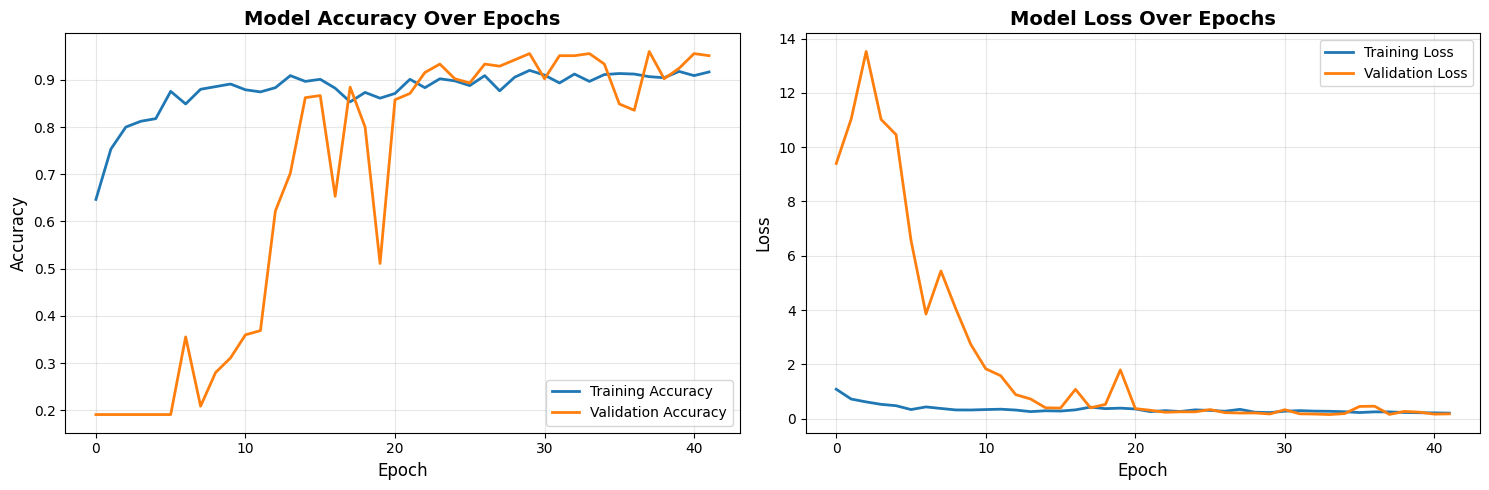

Training plots saved to: /content/drive/MyDrive/Colab Notebooks/nnfllproject/saved_models/training_plots.png


In [ ]:
plt.figure(figsize=(15, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'training_plots.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Training plots saved to: {os.path.join(MODEL_SAVE_DIR, 'training_plots.png')}")

Load model for testing

In [ ]:
# Load the best trained model
loaded_model = keras.models.load_model(BEST_MODEL_PATH)
print("Model loaded successfully!")
print(f"Model loaded from: {BEST_MODEL_PATH}")

# Verify model is working
loaded_model.summary()

Model loaded successfully!
Model loaded from: /content/drive/MyDrive/Colab Notebooks/nnfllproject/saved_models/best_weather_cnn_model.keras


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 58,196,942 (222.00 MB)

 Trainable params: 19,398,148 (74.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

 Optimizer params: 38,796,298 (148.00 MB)

 Image Prediction

Please upload an image file...


Saving 360_F_238122952_9f03DUbtqvX3vuWFo32nzPSuXJXWj3Ui.jpg to 360_F_238122952_9f03DUbtqvX3vuWFo32nzPSuXJXWj3Ui (2).jpg
Saving 360_F_374605226_3zlXWUfx8NGav7j0JEXESiKaYqM7HagA.jpg to 360_F_374605226_3zlXWUfx8NGav7j0JEXESiKaYqM7HagA (1).jpg
Saving 727c30f3e7097a05657888de9678957b.jpg to 727c30f3e7097a05657888de9678957b.jpg
Saving download (3).jpg to download (3).jpg

Processing: 360_F_238122952_9f03DUbtqvX3vuWFo32nzPSuXJXWj3Ui (2).jpg


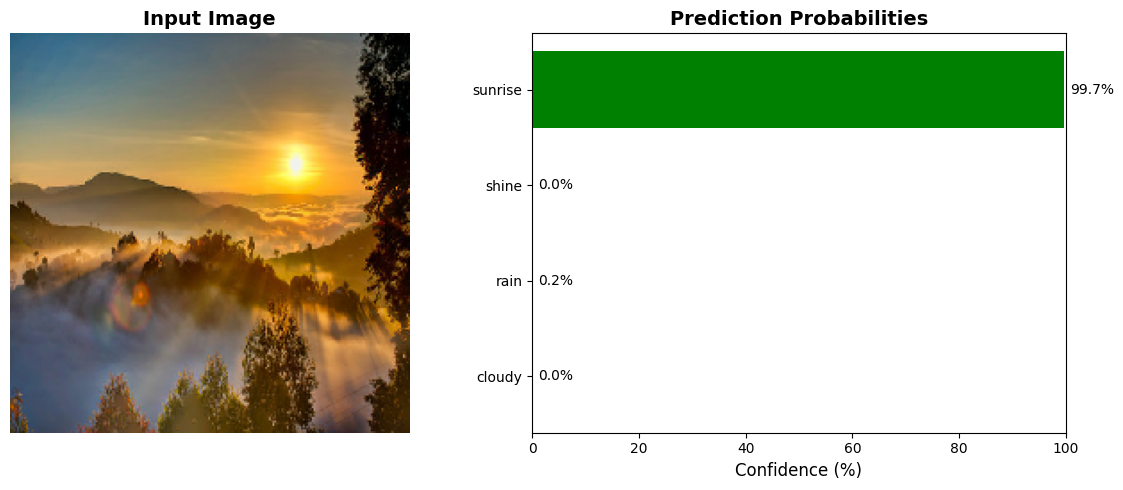


Predicted Class: SUNRISE
Confidence: 99.74%

All probabilities:
  cloudy: 0.04%
  rain: 0.18%
  shine: 0.03%
  sunrise: 99.74%

Processing: 360_F_374605226_3zlXWUfx8NGav7j0JEXESiKaYqM7HagA (1).jpg


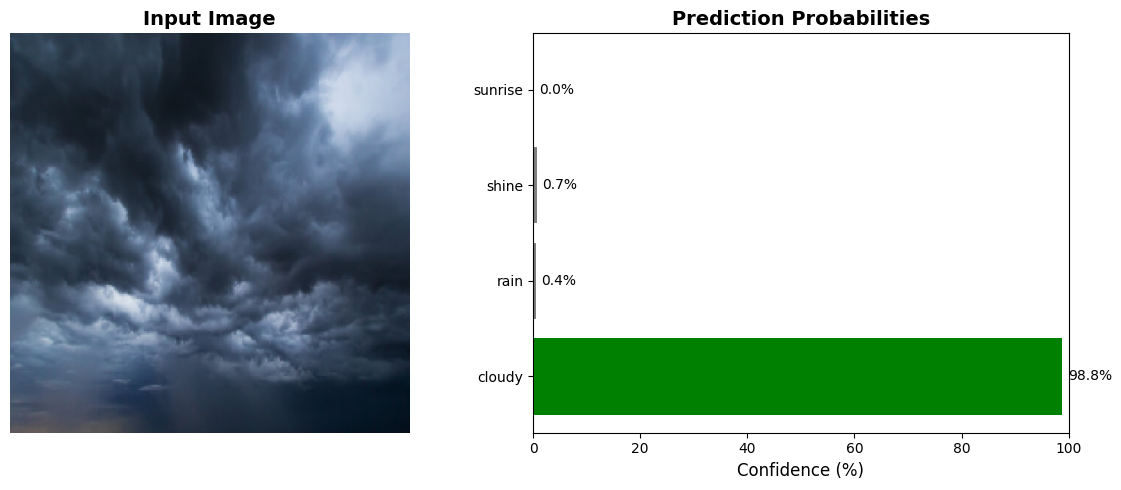


Predicted Class: CLOUDY
Confidence: 98.82%

All probabilities:
  cloudy: 98.82%
  rain: 0.44%
  shine: 0.70%
  sunrise: 0.04%

Processing: 727c30f3e7097a05657888de9678957b.jpg


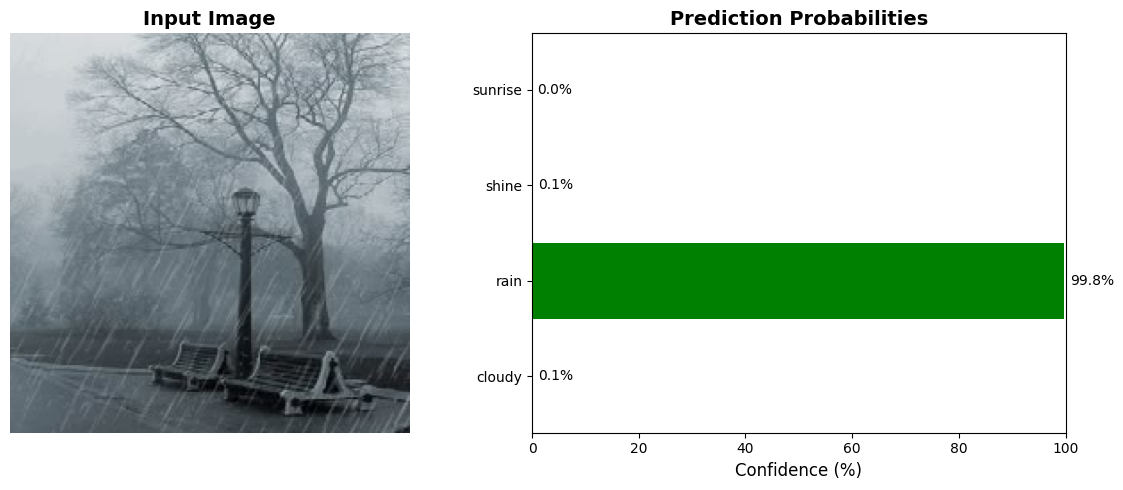


Predicted Class: RAIN
Confidence: 99.79%

All probabilities:
  cloudy: 0.15%
  rain: 99.79%
  shine: 0.07%
  sunrise: 0.00%

Processing: download (3).jpg


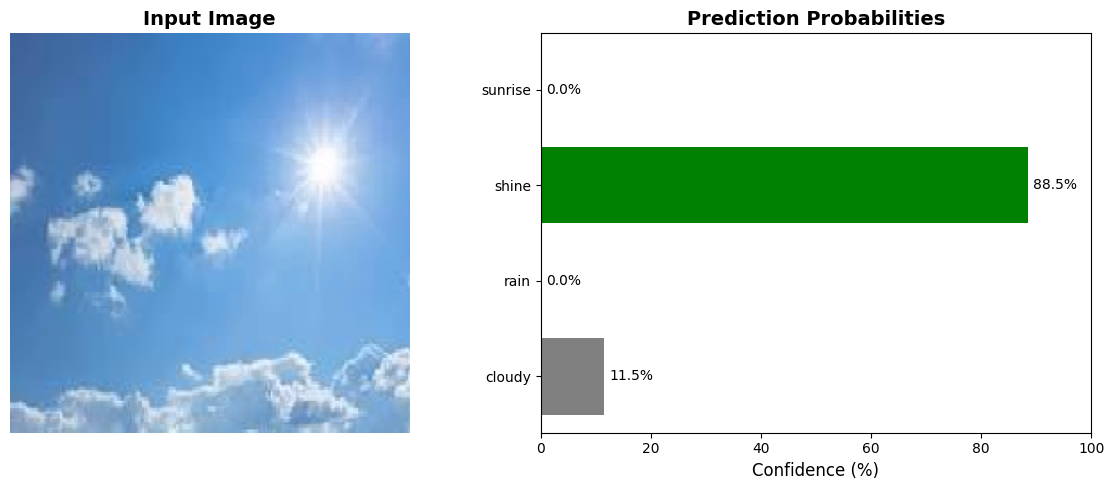


Predicted Class: SHINE
Confidence: 88.49%

All probabilities:
  cloudy: 11.48%
  rain: 0.02%
  shine: 88.49%
  sunrise: 0.01%


In [ ]:
print("Please upload an image file...")
uploaded = files.upload()


for filename in uploaded.keys():
    print(f"\nProcessing: {filename}")

    # Load and preprocess the image
    img = image.load_img(filename, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0


    # Make prediction
    predictions = loaded_model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx] * 100
    predicted_class = class_names[predicted_class_idx]

    # Visualize
    plt.figure(figsize=(12, 5))

    # Display image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f'Input Image', fontsize=14, fontweight='bold')
    plt.axis('off')

    # Display prediction probabilities
    plt.subplot(1, 2, 2)
    colors = ['green' if i == predicted_class_idx else 'gray' for i in range(len(class_names))]
    bars = plt.barh(class_names, predictions[0] * 100, color=colors)
    plt.xlabel('Confidence (%)', fontsize=12)
    plt.title('Prediction Probabilities', fontsize=14, fontweight='bold')
    plt.xlim(0, 100)

    # Add percentage labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height()/2,
                f'{predictions[0][i]*100:.1f}%',
                ha='left', va='center', fontsize=10)


    plt.tight_layout()
    plt.show()

    print(f"\n{'='*50}")
    print(f"Predicted Class: {predicted_class.upper()}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"{'='*50}")
    print(f"\nAll probabilities:")
    for i, class_name in enumerate(class_names):
        print(f"  {class_name}: {predictions[0][i]*100:.2f}%")

Confusion matrix

Model loaded successfully!

Generating predictions on validation set...
Total predictions: 225
Classes: ['cloudy', 'rain', 'shine', 'sunrise']

Confusion Matrix:
[[59  0  1  0]
 [ 0 43  0  0]
 [ 6  0 43  2]
 [ 0  0  0 71]]

Plotting Confusion Matrix...


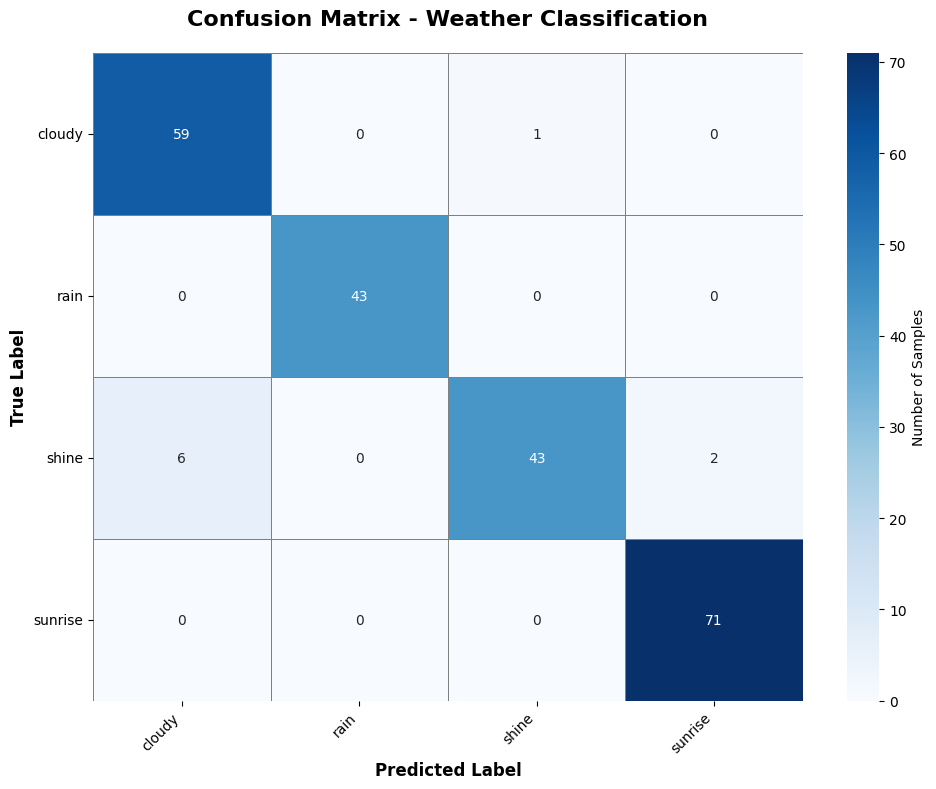

In [ ]:
model = keras.models.load_model(BEST_MODEL_PATH)
print("Model loaded successfully!")

print("\nGenerating predictions on validation set...")

# Reset the validation data to start from beginning
validation_data.reset()

# Get true labels and predictions
y_true = []
y_pred = []

# Iterate through all batches in validation set
steps = len(validation_data)
for i in range(steps):
    x_batch, y_batch = next(validation_data)
    predictions = model.predict(x_batch, verbose=0)

    # Get true labels (convert from one-hot to class indices)
    true_labels = np.argmax(y_batch, axis=1)
    # Get predicted labels
    pred_labels = np.argmax(predictions, axis=1)

    y_true.extend(true_labels)
    y_pred.extend(pred_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Total predictions: {len(y_true)}")

# Get class names
class_names = list(validation_data.class_indices.keys())
print(f"Classes: {class_names}")

# Calculate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Plot Confusion Matrix (Heatmap)
def plot_confusion_matrix(cm, class_names):
    """Plot confusion matrix as a heatmap"""
    plt.figure(figsize=(10, 8))

    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                cbar_kws={'label': 'Number of Samples'},
                linewidths=0.5, linecolor='gray')

    plt.title('Confusion Matrix - Weather Classification',
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\nPlotting Confusion Matrix...")
plot_confusion_matrix(cm, class_names)

Normalized Confusion Matrix (Percentages)


Plotting Normalized Confusion Matrix...


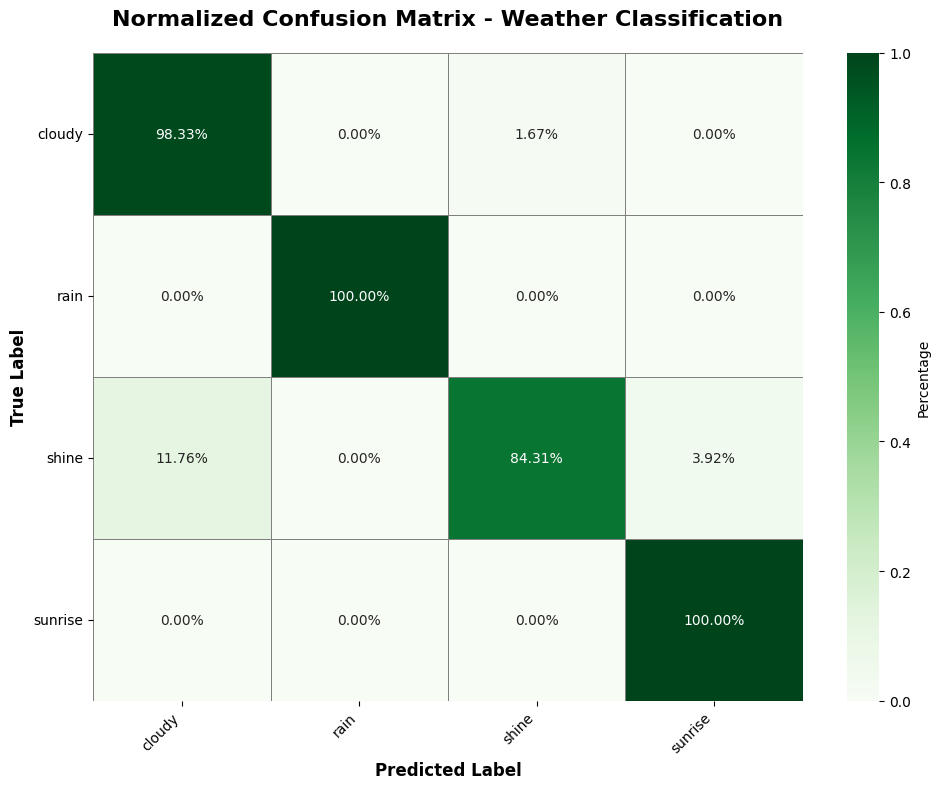

In [ ]:
def plot_normalized_confusion_matrix(cm, class_names):
    """Plot normalized confusion matrix (percentages)"""
    # Normalize by row (true labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))

    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=class_names,
                yticklabels=class_names,
                cbar_kws={'label': 'Percentage'},
                linewidths=0.5, linecolor='gray',
                vmin=0, vmax=1)

    plt.title('Normalized Confusion Matrix - Weather Classification',
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig('confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\nPlotting Normalized Confusion Matrix...")
plot_normalized_confusion_matrix(cm, class_names)

Calculate classification matrix and overall accuracy

In [ ]:
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Calculate Overall Metrics
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print("\nKey Findings:")
print(f"  • Best performing class:    {class_names[np.argmax(cm.diagonal()/cm.sum(axis=1))]}")
print(f"  • Worst performing class:   {class_names[np.argmin(cm.diagonal()/cm.sum(axis=1))]}")
print(f"  • Overall accuracy:         {accuracy*100:.2f}%")
print("="*70)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      cloudy     0.9077    0.9833    0.9440        60
        rain     1.0000    1.0000    1.0000        43
       shine     0.9773    0.8431    0.9053        51
     sunrise     0.9726    1.0000    0.9861        71

    accuracy                         0.9600       225
   macro avg     0.9644    0.9566    0.9588       225
weighted avg     0.9616    0.9600    0.9592       225


SUMMARY

Key Findings:
  • Best performing class:    rain
  • Worst performing class:   shine
  • Overall accuracy:         96.00%
